## Phase 04: Model Optimization & Advanced Engineering

**Goal:**
To refine the candidate models from Phase 03 through rigorous hyperparameter tuning and advanced data strategies.

**Strategy:**
1.  **Pipeline Construction:** Developing dedicated pipelines for Naive Bayes (Probabilistic) and SVM (Geometric).
2.  **Hyperparameter Tuning:** Using `GridSearchCV` with Stratified K-Fold to maximize F1-Score.
3.  **Data Strategy:**
    * Evaluating **Class Weights** vs. **SMOTE** for imbalance handling.
    * **Feature Engineering:** Integrating structural features (Message Length, Symbols) via `FeatureUnion`.
4.  **Selection:** Choosing the final production model based on generalization performance on the held-out Test Set.

### Step 4_0 : Load dataset

In [1]:
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    make_scorer, roc_auc_score, precision_score, recall_score
)

# Set styles
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.append(os.path.abspath("../"))
from src.preprocessing import load_splits_xy

# Load splits (same as Phase 03)
X_train, X_val, X_test, y_train, y_val, y_test = load_splits_xy()

print("=== Data Splits ===")
print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Train labels: {Counter(y_train)}")
print(f"Val labels: {Counter(y_val)}")
print(f"Test labels: {Counter(y_test)}")

=== Data Splits ===
Train: 3093 | Val: 1031 | Test: 1032
Train labels: Counter({0: 2708, 1: 385})
Val labels: Counter({0: 903, 1: 128})
Test labels: Counter({0: 904, 1: 128})


###  Step 4_1. Feature Engineering


In this step, we implement the requested feature engineering tasks to capture **structural patterns** of spam messages (beyond just words).

**Implemented Features:**
1.  **Message Length:** Calculates total characters (Spam tends to have specific length patterns).
2.  **Content Counts:**
    * **Special Characters:** Counts symbols like `!`, `$`, `#` (often used in spam).
    * **Numbers:** Counts digits (phone numbers, prize amounts).
    * **URLs:** Detects links using Regex (common in phishing).
3.  **Feature Combinations:**
    * **Uppercase Ratio:** Calculates `Uppercase Count / Total Length` to detect "shouting" or urgency (e.g., "FREE NOW").

**Output:** A matrix of 5 numerical features is generated for all splits (Train, Val, Test).

In [2]:
# Combine train+val for tuning (will use proper CV to avoid leakage)
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print(f"\nCombined train+val: {len(X_train_full)} samples for hyperparameter tuning")


Combined train+val: 4124 samples for hyperparameter tuning


In [3]:
import numpy as np
import re

def extract_manual_features(texts):
    """
    Extract manual features from text messages.
    Returns: (n_samples, 5) array with: length, special_chars, numbers, urls, uppercase_ratio
    """
    features = []
    for text in texts:
        text_str = str(text)
        
        # Add message length as a feature
        length = len(text_str)
        
        # Add count of special characters, numbers, URLs
        # Special Characters
        special_chars = sum(1 for c in text_str if not c.isalnum() and not c.isspace())
        # Numbers
        numbers = sum(1 for c in text_str if c.isdigit())
        # URLs
        urls = len(re.findall(r'http\S+|www\S+', text_str))
        
        # Experiment with feature combinations
        uppercase = sum(1 for c in text_str if c.isupper())
        uppercase_ratio = uppercase / max(1, length) 
        
        features.append([length, special_chars, numbers, urls, uppercase_ratio])
    
    return np.array(features, dtype=np.float32)

# Extract features for all splits
manual_train = extract_manual_features(X_train)
manual_val = extract_manual_features(X_val)
manual_train_full = extract_manual_features(X_train_full)

print("=== Manual Features Extracted ===")
print(f"Shape: {manual_train_full.shape}")
print(f"Columns: [length, special_chars, numbers, urls, uppercase_ratio]")
print(f"\nSample statistics (train):")
for i, col in enumerate(['Length', 'Special Chars', 'Numbers', 'URLs', 'Uppercase Ratio']):
    print(f"  {col}: mean={manual_train[:, i].mean():.2f}, std={manual_train[:, i].std():.2f}")

=== Manual Features Extracted ===
Shape: (4124, 5)
Columns: [length, special_chars, numbers, urls, uppercase_ratio]

Sample statistics (train):
  Length: mean=71.02, std=50.11
  Special Chars: mean=0.00, std=0.04
  Numbers: mean=0.00, std=0.00
  URLs: mean=0.02, std=0.14
  Uppercase Ratio: mean=0.00, std=0.00


####  Why Feature Engineering MUST Precede Imbalance Handling?

In the machine learning pipeline, the order of operations is critical. We performed **Feature Engineering** first and **Class Imbalance Handling** (specifically SMOTE) second. Here is the technical reasoning:

#### 1. SMOTE requires Numerical Vectors, not Raw Text
Algorithms like **SMOTE** (Synthetic Minority Over-sampling Technique) operate in a mathematical vector space (Euclidean space). They generate new samples by calculating distances and interpolating between points.
* **Raw Text:** "Win 1000$ prize!" (SMOTE cannot understand this).
* **Feature Vectors:** `[Length=15, Caps=0.5, TFIDF_win=0.3...]` (SMOTE works on this).

**Conclusion:** We must first convert the raw text into numerical features (via Feature Engineering & Vectorization) before SMOTE can process it.

#### 2. The "Ghost Data" Problem (Impossible Reverse Engineering)
If we applied SMOTE first (hypothetically), we would face a logical paradox:
1.  SMOTE creates a new synthetic sample (a vector of numbers).
2.  This synthetic sample **does not have corresponding raw text**. It is just a point in space.
3.  If we then tried to run `extract_manual_features()`, the function would fail because there is no text string to check for URLs, capital letters, or special characters.

#### 3. The Correct Pipeline Flow
To ensure the synthetic samples accurately represent both the *semantic content* (TF-IDF) and the *structural behavior* (Manual Features) of spam, the pipeline must follow this order:

$$
\text{Raw Text} \xrightarrow{\text{1. Extract Features}} \text{Num Features} + \text{Text} \xrightarrow{\text{2. Vectorize}} \text{Full Numerical Matrix} \xrightarrow{\text{3. SMOTE}} \text{Balanced Training Set}
$$

> **Summary:** We extract features first so that when SMOTE creates a synthetic spam sample, it generates a "complete" mathematical profile (simulating both the words used AND the structural features like length/caps) simultaneously.

#### 4.1_1. Model Enhancement: Combining Text with Manual Features


In [4]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin

print("\n" + "="*80)
print("4.9. ADVANCED ENGINEERING: Text vs. Text+Structural Features (5-Fold CV)")
print("="*80)

class ManualFeatureTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return extract_manual_features(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = 'f1'

results_eng = []

# 1. Definining Pipelines

# --- Naive Bayes Pipelines ---
# A. Text Only (Baseline)
pipe_nb_text = Pipeline([
    ('vect', CountVectorizer(lowercase=True, max_features=5000, min_df=1)),
    ('clf', MultinomialNB(alpha=0.1))
])

# B. Text + Manual Features (Enhanced)
pipe_nb_plus = Pipeline([
    ('features', FeatureUnion([
        ('text', CountVectorizer(lowercase=True, max_features=5000, min_df=1)),
        ('manual', Pipeline([
            ('extractor', ManualFeatureTransformer()),
            ('scaler', MinMaxScaler()) # NB needs positive features
        ]))
    ])),
    ('clf', MultinomialNB(alpha=0.1))
])

# --- SVM Pipelines ---
# A. Text Only (Baseline)
pipe_svm_text = Pipeline([
    ('vect', TfidfVectorizer(lowercase=True, max_features=5000, min_df=1)),
    ('clf', LinearSVC(C=20.0, max_iter=10000, class_weight='balanced', random_state=42))
])

# B. Text + Manual Features (Enhanced)
pipe_svm_plus = Pipeline([
    ('features', FeatureUnion([
        ('text', TfidfVectorizer(lowercase=True, max_features=5000, min_df=1)),
        ('manual', Pipeline([
            ('extractor', ManualFeatureTransformer()),
            ('scaler', StandardScaler()) # SVM needs standard scaling
        ]))
    ])),
    ('clf', LinearSVC(C=20.0, max_iter=10000, class_weight='balanced', random_state=42))
])

# 2. Execution & Evaluation
experiments = [
    ('NB (Text Only)', pipe_nb_text),
    ('NB (Text + Features)', pipe_nb_plus),
    ('SVM (Text Only)', pipe_svm_text),
    ('SVM (Text + Features)', pipe_svm_plus)
]

print("Running Cross-Validation on Feature Engineering strategies...")

for name, pipeline in experiments:
    print(f"   -> Testing {name}...")
    # CV on FULL training data
    scores = cross_val_score(pipeline, X_train_full, y_train_full, cv=cv, scoring=scoring, n_jobs=-1)
    results_eng.append({
        'Model Config': name,
        'Mean F1': np.mean(scores),
        'Std Dev': np.std(scores)
    })

# 3. Final Report
df_eng_results = pd.DataFrame(results_eng)
df_eng_results = df_eng_results.sort_values(by='Model Config')

print("\n--- Feature Engineering Impact (CV Results) ---")
print(df_eng_results.to_string(index=False, float_format="%.4f"))

nb_base = df_eng_results[df_eng_results['Model Config'] == 'NB (Text Only)']['Mean F1'].values[0]
nb_plus = df_eng_results[df_eng_results['Model Config'] == 'NB (Text + Features)']['Mean F1'].values[0]
svm_base = df_eng_results[df_eng_results['Model Config'] == 'SVM (Text Only)']['Mean F1'].values[0]
svm_plus = df_eng_results[df_eng_results['Model Config'] == 'SVM (Text + Features)']['Mean F1'].values[0]

print(f"\n✅ IMPACT ANALYSIS:")
print(f"   NB Change:  {nb_plus - nb_base:+.4f}")
print(f"   SVM Change: {svm_plus - svm_base:+.4f}")

if (nb_plus > nb_base + 0.005) or (svm_plus > svm_base + 0.005):
    print("\n   -> Decision: Feature Engineering significantly improves performance.")
else:
    print("\n   -> Decision: Minimal or no improvement. Stick to Text-Only models (Simplicity).")


4.9. ADVANCED ENGINEERING: Text vs. Text+Structural Features (5-Fold CV)
Running Cross-Validation on Feature Engineering strategies...
   -> Testing NB (Text Only)...
   -> Testing NB (Text + Features)...
   -> Testing SVM (Text Only)...
   -> Testing SVM (Text + Features)...

--- Feature Engineering Impact (CV Results) ---
         Model Config  Mean F1  Std Dev
 NB (Text + Features)   0.9299   0.0186
       NB (Text Only)   0.9268   0.0185
SVM (Text + Features)   0.9261   0.0107
      SVM (Text Only)   0.9298   0.0110

✅ IMPACT ANALYSIS:
   NB Change:  +0.0032
   SVM Change: -0.0037

   -> Decision: Minimal or no improvement. Stick to Text-Only models (Simplicity).


#####  Advanced Engineering Analysis (CV Results)


To determine if structural metadata (e.g., message length, symbol counts) adds value beyond raw text, we conducted a **5-Fold Cross-Validation** experiment.

**Results Analysis (Mean F1-Score):**

| Model Configuration | Mean CV F1 | Std Dev | Impact of Features |
| :--- | :---: | :---: | :---: |
| **NB (Text Only)** | **0.9268** | 0.018 | - |
| NB (Text + Features) | 0.9299 | 0.019 | 🔼 +0.32% (Marginal) |
| **SVM (Text Only)** | **0.9298** | 0.011 | - |
| SVM (Text + Features) | 0.9261 | 0.011 | 🔽 -0.37% (Noise) |

**Conclusion & Decision:**
* **Diminishing Returns:** The engineered features provided negligible improvement for Naive Bayes (+0.003) and actually degraded SVM performance. This suggests that the text content itself (Bag-of-Words/TF-IDF) already captures the necessary signal to distinguish spam (e.g., specific words likely correlate strongly with message length).
* **Final Decision:** We **reject** the additional features to maintain model simplicity and inference speed. We proceed with the **Text-Only** architecture.

### Step 4_2. Class imbalance

In [5]:
# Class imbalance analysis
train_ham = sum(y_train == 0)
train_spam = sum(y_train == 1)
imbalance_ratio = train_ham / train_spam

print("=== Class Imbalance Analysis ===")
print(f"Train: {train_ham} ham (0), {train_spam} spam (1)")
print(f"Imbalance ratio (ham/spam): {imbalance_ratio:.2f}:1")
print(f"Spam percentage: {100*train_spam/(train_spam+train_ham):.2f}%")



=== Class Imbalance Analysis ===
Train: 2708 ham (0), 385 spam (1)
Imbalance ratio (ham/spam): 7.03:1
Spam percentage: 12.45%


#### Comparison of Handling Strategies



| Strategy | Mechanism | Pros | Cons | Best For |
| :--- | :--- | :--- | :--- | :--- |
| **Class Weights** | Penalize majority class during training | ✓ Simple, fast, no data loss | ✗ Slightly less powerful | Moderate imbalance (5:1 to 10:1) |
| **SMOTE (Oversampling)** | Generate synthetic minority samples | ✓ Powerful, proven effective | ✗ Risk of overfitting | Large datasets, complex patterns |
| **Undersampling** | Remove majority class samples | ✓ Fast training, reduced data | ✗ Information loss (data deletion) | Very large datasets only |

---

#####  RECOMMENDATION FOR THIS DATASET

** Dataset Statistics (Train Split):**
* **Current Ratio:** `7.03:1` (Moderate Imbalance)
* **Minority Class (Spam):** 385 samples (Enough data to learn features)
* **Majority Class (Ham):** 2708 samples

** PRIMARY STRATEGY: Class Weights (`class_weight='balanced'`)**
> **Reason:** Simple and effective for a ~7:1 ratio. It preserves all 2708 legitimate emails without deleting valuable information.

** SECONDARY STRATEGY: SMOTE**
> **Reason:** Use as a fallback if Class Weights doesn't yield good recall. It generates synthetic samples to help the model boundaries.

** NOT RECOMMENDED: Undersampling**
> **Reason:** To balance the classes, you would need to delete **~2323** legitimate samples (reducing Ham from 2708 to 385). This causes massive information loss (~85% of majority data).

In [6]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import resample
from IPython.display import display, Markdown

results = []

# --- A. Original Data (Class Weights Strategy) ---
ham_orig = sum(y_train_full == 0)
spam_orig = sum(y_train_full == 1)
results.append({
    'Strategy': 'Original (Class Weights)',
    'Total Samples': len(X_train_full),
    'Ham': ham_orig,
    'Spam': spam_orig,
    'Ratio': f"{ham_orig/spam_orig:.2f}:1",
    'Data Loss': '0%',
    'Status': '✅ RECOMMENDED'
})

# --- B. SMOTE Strategy (Simulation) ---
try:
    from imblearn.over_sampling import SMOTE
    # Vectorize strictly for simulation
    vec_sim = TfidfVectorizer(max_features=1000) 
    X_sim = vec_sim.fit_transform(X_train_full)
    
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_smote, y_smote = smote.fit_resample(X_sim, y_train_full)
    
    ham_smote = sum(y_smote == 0)
    spam_smote = sum(y_smote == 1)
    
    results.append({
        'Strategy': 'SMOTE (Oversampling)',
        'Total Samples': X_smote.shape[0],
        'Ham': ham_smote,
        'Spam': spam_smote,
        'Ratio': f"{ham_smote/spam_smote:.2f}:1",
        'Data Loss': '0% (Synthetic Added)',
        'Status': ' ALTERNATIVE'
    })
except ImportError:
    results.append({'Strategy': 'SMOTE', 'Status': ' Not Installed'})

# --- C. Undersampling Strategy (Simulation) ---
X_ham = X_train_full[y_train_full == 0]
X_spam = X_train_full[y_train_full == 1]
# Downsample majority
X_ham_under = resample(X_ham, replace=False, n_samples=len(X_spam), random_state=42)

total_under = len(X_ham_under) + len(X_spam)
loss_pct = (len(X_train_full) - total_under) / len(X_train_full) * 100

results.append({
    'Strategy': 'Undersampling',
    'Total Samples': total_under,
    'Ham': len(X_ham_under),
    'Spam': len(X_spam),
    'Ratio': '1.00:1',
    'Data Loss': f' -{loss_pct:.1f}% (High Risk)',
    'Status': ' AVOID'
})

# 2. CREATE STYLED DATAFRAME
df_results = pd.DataFrame(results)

# Define a function to color the status
def color_status(val):
    color = 'black'
    if 'RECOMMENDED' in val: color = 'green'
    elif 'AVOID' in val: color = 'red'
    elif 'ALTERNATIVE' in val: color = 'blue'
    return f'color: {color}; font-weight: bold'

# Display Header
display(Markdown("###  Strategy Impact Simulation"))
display(Markdown("Comparing how different strategies affect dataset size and balance:"))

# Render the styled table
styler = df_results.style.applymap(color_status, subset=['Status'])\
                 .set_properties(**{'text-align': 'center'})\
                 .set_table_styles([dict(selector='th', props=[('text-align', 'center')])])\
                 .hide(axis="index") 

display(styler)

# Print Summary Text
print("-" * 60)
print(f"🔹 Recommendation: Use 'Class Weights'. It keeps all {len(X_train_full)} samples.")
print(f"🔸 Warning: Undersampling deletes {len(X_train_full) - total_under} real emails!")
print("-" * 60)

###  Strategy Impact Simulation

Comparing how different strategies affect dataset size and balance:

Strategy,Total Samples,Ham,Spam,Ratio,Data Loss,Status
Original (Class Weights),4124,3611,513,7.04:1,0%,✅ RECOMMENDED
SMOTE (Oversampling),7222,3611,3611,1.00:1,0% (Synthetic Added),ALTERNATIVE
Undersampling,1026,513,513,1.00:1,-75.1% (High Risk),AVOID


------------------------------------------------------------
🔹 Recommendation: Use 'Class Weights'. It keeps all 4124 samples.
🔸 Warning: Undersampling deletes 3098 real emails!
------------------------------------------------------------


#### 4_2_1. Comparative Experiment: SMOTE vs. Class Weights



**Objective:**
Throughout Phase 4, we relied on **Class Weights** (Cost-Sensitive Learning) to handle the data imbalance. In this final experimental step, we test an alternative strategy: **SMOTE (Synthetic Minority Over-sampling Technique)**.

**The Experiment:**
We will train separate instances of Naive Bayes and SVM on the **SMOTE-augmented training set** (`X_train_smote`) and evaluate them on the original, untouched Test Set.

**Goal:**
To determine if generating synthetic spam examples provides a tangible advantage over simply penalizing the model for missing spam (Class Weights). This serves as a final validation of our chosen strategy.

**point:**
Naive Bayes does not support class weights because it is a probabilistic generative model without an explicit loss function.
Class imbalance is handled implicitly through class priors rather than cost-sensitive optimization.

In [7]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline as SklearnPipeline
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("4.8. ROBUST COMPARISON: SMOTE vs. Class Weights (using 5-Fold CV)")
print("="*80)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_available = True
except ImportError:
    smote_available = False
    print("⚠️ imbalanced-learn library not found. Skipping SMOTE CV.")

if smote_available:
    print("\n🔄 Running 5-Fold Cross-Validation to ensure statistical validity...")
    print("   Note: SMOTE is applied ONLY within training folds to prevent data leakage.")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = 'f1' # F1-score for positive class (spam)

    results_cv = []

    # ==========================================
    # 1. Naive Bayes Strategies
    # ==========================================
    # Strategy A: Baseline (Standard)
    # NB doesn't have class_weight, so standard is baseline
    pipe_nb_base = SklearnPipeline([
        ('vect', CountVectorizer(lowercase=True, max_features=5000, min_df=2)),
        ('clf', MultinomialNB(alpha=0.1)) # Optimized alpha
    ])
    
    # Strategy B: SMOTE
    pipe_nb_smote = ImbPipeline([
        ('vect', CountVectorizer(lowercase=True, max_features=5000, min_df=2)),
        ('smote', SMOTE(random_state=42)),
        ('clf', MultinomialNB(alpha=0.1))
    ])

    # ==========================================
    # 2. SVM Strategies
    # ==========================================
    # Strategy A: Class Weights (Cost-Sensitive)
    pipe_svm_weighted = SklearnPipeline([
        ('vect', TfidfVectorizer(lowercase=True, max_features=5000, min_df=2)),
        ('clf', LinearSVC(C=20.0, max_iter=5000, class_weight='balanced', random_state=42))
    ])

    # Strategy B: SMOTE (No Class Weights)
    pipe_svm_smote = ImbPipeline([
        ('vect', TfidfVectorizer(lowercase=True, max_features=5000, min_df=2)),
        ('smote', SMOTE(random_state=42)),
        ('clf', LinearSVC(C=20.0, max_iter=5000, random_state=42)) # No class_weight
    ])

    # ==========================================
    # 3. Execution & Comparison
    # ==========================================
    models_to_test = [
        ('NB (Baseline)', pipe_nb_base),
        ('NB + SMOTE', pipe_nb_smote),
        ('SVM (Class Weight)', pipe_svm_weighted),
        ('SVM + SMOTE', pipe_svm_smote)
    ]

    for name, pipeline in models_to_test:
        print(f"   -> train_full {name}...")
        # Cross-validation on FULL training data (X_train_full)
        # Note: We use X_train_full because CV splits it internally
        scores = cross_val_score(pipeline, X_train_full, y_train_full, cv=cv, scoring=scoring, n_jobs=-1)
        results_cv.append({
            'Strategy': name,
            'Mean F1': np.mean(scores),
            'Std Dev': np.std(scores)
        })

    # ==========================================
    # 4. Reporting
    # ==========================================
    df_cv_results = pd.DataFrame(results_cv)
    df_cv_results = df_cv_results.sort_values(by='Mean F1', ascending=False)
    
    print("\n--- 5-Fold Cross-Validation Results ---")
    print(df_cv_results.to_string(index=False, float_format="%.4f"))

    # Analysis
    best_strategy = df_cv_results.iloc[0]['Strategy']
    print(f"\n✅ CONCLUSION:")
    print(f"   The most robust strategy based on Cross-Validation is: {best_strategy}")
    
    if "SMOTE" not in best_strategy:
        print("   -> Decision: SMOTE does not improve generalization. Proceed with standard/weighted methods.")
        print("   -> Reason: SMOTE in high-dimensional text data often introduces noise.")
    else:
        print("   -> Decision: SMOTE provides a consistent improvement.")

else:
    print("Please install imbalanced-learn: pip install imbalanced-learn")


4.8. ROBUST COMPARISON: SMOTE vs. Class Weights (using 5-Fold CV)

🔄 Running 5-Fold Cross-Validation to ensure statistical validity...
   Note: SMOTE is applied ONLY within training folds to prevent data leakage.
   -> train_full NB (Baseline)...
   -> train_full NB + SMOTE...
   -> train_full SVM (Class Weight)...
   -> train_full SVM + SMOTE...

--- 5-Fold Cross-Validation Results ---
          Strategy  Mean F1  Std Dev
     NB (Baseline)   0.9169   0.0191
SVM (Class Weight)   0.8850   0.0168
        NB + SMOTE   0.8818   0.0299
       SVM + SMOTE   0.7932   0.0152

✅ CONCLUSION:
   The most robust strategy based on Cross-Validation is: NB (Baseline)
   -> Decision: SMOTE does not improve generalization. Proceed with standard/weighted methods.
   -> Reason: SMOTE in high-dimensional text data often introduces noise.


##### Robust Comparison: SMOTE vs. Class Weights (5-Fold CV)

**Objective:**
To validate our imbalance handling strategy rigorously, we compared **Class Weighting** (and standard distribution) against **SMOTE** using **5-Fold Stratified Cross-Validation**.
* **Note:** SMOTE was applied *only* within the training folds during CV to prevent data leakage.

**Results Analysis (Mean F1-Score):**

| Strategy | Mean CV F1-Score | Std Dev | Impact of SMOTE |
| :--- | :---: | :---: | :---: |
| **NB (Baseline)** | **0.9169** | 0.019 | - |
| NB + SMOTE | 0.8818 | 0.030 | 🔽 -3.83% |
| **SVM (Class Weight)** | **0.8850** | 0.017 | - |
| SVM + SMOTE | 0.7932 | 0.015 | 🔽 **-10.37%** |

**Conclusion & Decision:**
The Cross-Validation results confirm with high statistical confidence that **SMOTE is detrimental** to model performance for this high-dimensional text dataset.

* **Performance Drop:** SMOTE caused a significant drop in F1-score for both models, particularly destroying SVM performance (-10%).
* **Reasoning:** In sparse text vectors (TF-IDF/BoW), SMOTE generates synthetic samples by interpolating between points. These synthetic points likely represent meaningless combinations of words, introducing "semantic noise" rather than helpful minority class signals.
* **Final Decision:** We officially **reject SMOTE**. We will proceed with the **Standard/Weighted** strategies which proved to be more robust and generalizable.

### Step 4_3. Baseline Model (Before Optimization)


### Baseline Evaluation: Pre-Optimization Benchmark

This section establishes a performance benchmark using standard algorithms prior to any optimization or feature engineering.

#### Key Implementation Details:

- **Data Utilization (Train + Validation Merge):**
  - The models are trained and evaluated on the combined dataset `X_train_full` and `y_train_full`.
  - **Reasoning:** Merging the training and validation sets maximizes the amount of data available for learning, leading to a more reliable estimation of baseline performance. The **Test Set is strictly reserved for final evaluation only**.

- **Evaluation Methodology (Cross-Validation):**
  - **Method:** **5-Fold Stratified Cross-Validation**.
  - **Reasoning:** Cross-validation provides a more stable and statistically reliable estimate of baseline performance compared to a single hold-out split. Stratification ensures that the class imbalance ratio is preserved across all folds. The Test Set is not used at this stage.

- **Performance Metric:**
  - **Primary Metric:** `f1_score` (with `pos_label=1`).
  - **Reasoning:** Due to the imbalanced nature of the dataset (Ham > Spam), Accuracy can be misleading. The F1-score offers a balanced evaluation by jointly considering Precision and Recall for the minority (Spam) class.

- **Imbalance Handling:**
  - **SVM Strategy:** Uses `class_weight='balanced'` to explicitly penalize misclassification of the minority class.
  - **NB Strategy:** Native MultinomialNB is used without class weighting, as it implicitly accounts for class imbalance through learned class priors.

- **Feature Extraction Defaults:**
  - **Constraints:** Both vectorizers are configured with `max_features=5000` and `min_df=2`.
  - **Reasoning:** These constraints reduce noise by filtering out extremely rare terms (e.g., typos) and limit dimensionality to mitigate overfitting during the baseline evaluation phase.


In [8]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

baseline_nb = Pipeline([
    ('vect', CountVectorizer(lowercase=True, max_features=5000, min_df=2)),
    ('clf', MultinomialNB(alpha=1.0))
])

baseline_svm = Pipeline([
    ('vect', TfidfVectorizer(lowercase=True, max_features=5000, min_df=2)),
    ('clf', LinearSVC(C=1.0, max_iter=5000, random_state=42, class_weight='balanced'))
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== BASELINE EVALUATION (5-Fold CV on Train+Val) ===")
print("Calculating baseline performance without data leakage...\n")


nb_scores = cross_val_score(baseline_nb, X_train_full, y_train_full, cv=cv_strategy, scoring='f1')
baseline_nb_f1 = nb_scores.mean()

print(f"--- MultinomialNB + BoW (Baseline) ---")
print(f"Mean CV F1-Score: {baseline_nb_f1:.4f}  (Std: {nb_scores.std():.4f})")

svm_scores = cross_val_score(baseline_svm, X_train_full, y_train_full, cv=cv_strategy, scoring='f1')
baseline_svm_f1 = svm_scores.mean()

print(f"\n--- LinearSVC + TF-IDF (Baseline) ---")
print(f"Mean CV F1-Score: {baseline_svm_f1:.4f}  (Std: {svm_scores.std():.4f})")

=== BASELINE EVALUATION (5-Fold CV on Train+Val) ===
Calculating baseline performance without data leakage...

--- MultinomialNB + BoW (Baseline) ---
Mean CV F1-Score: 0.9164  (Std: 0.0235)

--- LinearSVC + TF-IDF (Baseline) ---
Mean CV F1-Score: 0.9209  (Std: 0.0197)


### Step 4_4. Hyperparameter Tuning with GridSearchCV



####  Step 4_4_0. Hyperparameter Tuning Setup



* **Validation Strategy:**
  * **Technique:** `5-Fold Stratified Cross-Validation`
  * **Rationale:** "Stratified" ensures that the minority class (Spam) is represented equally (approx. 13%) in every fold, preventing biased training batches.

* **Optimization Metric:**
  * **Metric:** `F1-Score` (Targeting `pos_label=1` aka Spam)
  * **Rationale:** Accuracy is misleading for imbalanced data. We optimize specifically for the trade-off between Precision (low false alarms) and Recall (catching spam).

* **Data Scope:**
  * **Input:** Full Training Data (`X_train` + `X_val`)
  * **Process:** The GridSearchCV will automatically split this data into training and validation sets 5 times internally.

In [9]:
# Setup cross-validation and scoring
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scorer = make_scorer(f1_score, pos_label=1)

print("=== GridSearchCV Setup ===")
print(f"Cross-validation: 5-fold Stratified")
print(f"Scoring metric: F1-score (pos_label=1 for spam)")
print(f"Data: {len(X_train_full)} samples (train+val combined)")

=== GridSearchCV Setup ===
Cross-validation: 5-fold Stratified
Scoring metric: F1-score (pos_label=1 for spam)
Data: 4124 samples (train+val combined)


#### Step 4_4_1: Optimization Process: Multinomial Naive Bayes


To refine the Naive Bayes model, we executed a systematic hyperparameter tuning process designed to maximize spam detection capability.

**Execution Details:**

* **Search Strategy:** `Grid Search` was employed to exhaustively test **72** different combinations of feature extraction and model smoothing parameters.
* **Validation Method:** `5-Fold Stratified Cross-Validation` was used for every combination (Total fits: 360). This ensures the selected parameters are robust across different data subsets.
* **Target Metric:** The optimization objective was set to **F1-Score (Class 1: Spam)** to prioritize the balance between precision and recall in this imbalanced dataset.

**Parameters Tuned:**
1.  **Vocabulary Size:** Tested `max_features` at 3000, 5000, and 10000.
2.  **Noise Filtering:** Tested `min_df` thresholds of 1, 2, and 3.
3.  **Context Awareness:** Experimented with Unigrams `(1,1)` vs. Unigrams + Bigrams `(1,2)`.
4.  **Smoothing:** Adjusted `alpha` (0.01 to 1.0) to control model complexity.
Parallel processing (n_jobs=-1) was enabled to accelerate cross-validation, and verbose logging was used to monitor training progress.

In [10]:
# Model Refinement & Optimization

#  Define Pipeline (Connects text preprocessing with the model)
pipeline_nb = Pipeline([
    ('vect', CountVectorizer(lowercase=True)),
    ('clf', MultinomialNB())
])

# Define Search Space (Grid) for parameter experimentation
param_grid_nb = {
    # Maximum features : Test vocabulary limits (3k, 5k, 10k)
    'vect__max_features': [3000, 5000, 10000],
    
    # Min/max document frequency : Test filtering rare words (Noise reduction)
    'vect__min_df': [1, 2, 3],
    
    # n-gram ranges: Test Unigrams vs. Bigrams context
    'vect__ngram_range': [(1, 1), (1, 2)],
    
    # Hyperparameter tuning : Test model smoothing parameter (Alpha)
    'clf__alpha': [0.01, 0.1, 0.5, 1.0],
}

# 3. Grid Search Configuration
grid_nb = GridSearchCV(
    pipeline_nb,
    param_grid_nb,
    
    # Optimization target: F1-Score for imbalanced class (Spam)
    scoring=f1_scorer,
    
    # Using 5-Fold Stratified CV 
    cv=cv,
    n_jobs=-1,    # Use all available CPU cores
    verbose=2,
    return_train_score=True
)

print("\n=== Tuning MultinomialNB (this may take a moment...) ===")

grid_nb.fit(X_train_full, y_train_full)

# Display final results
print(f"\nBest NB parameters: {grid_nb.best_params_}")
print(f"Best CV F1-score: {grid_nb.best_score_:.4f}")

# Save the best model found
best_nb = grid_nb.best_estimator_


=== Tuning MultinomialNB (this may take a moment...) ===
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best NB parameters: {'clf__alpha': 0.1, 'vect__max_features': 5000, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}
Best CV F1-score: 0.9268


**Optimization Result: Multinomial Naive Bayes**

The Grid Search successfully identified optimal hyperparameters within the search space, achieving a **Best CV F1-Score of 0.9268**.

* **Selected Parameters Analysis:** *
  * **`max_features: 5000`**: This value was selected over 3000 and 10000, indicating an optimal balance between vocabulary richness and noise reduction. The optimum lies centrally within the search range.
  * **`alpha: 0.1`**: The model preferred a lower smoothing parameter (0.1) compared to the default (1.0), suggesting that the data is sufficient to trust the empirical probabilities without heavy regularization.
  * **`ngram_range: (1, 1)`**: Simple Unigrams outperformed Bigrams, likely due to the short nature of SMS messages where context is less complex.

**Conclusion:** The hyperparameters have converged to a stable optimum. We proceed to optimize the SVM model.

#### Step 4_4_2: Optimization Process: Linear Support Vector Machine (SVM)

Following the Naive Bayes tuning, we proceeded to optimize the LinearSVC model, which is known for its robustness in high-dimensional text classification.

**Key Optimization Strategies:**

* **Handling Imbalance (Class Weights):**
    * Unlike Naive Bayes, the SVM implementation allows for explicit class weighting. We set `class_weight='balanced'`, which automatically adjusts weights inversely proportional to class frequencies in the input data. This ensures the model pays significantly more attention to the minority class (Spam).

* **Regularization Tuning (Parameter C):**
    * We introduced the `C` parameter grid `[0.1, 0.5, 1.0, 2.0, 5.0]`.
    * **Role of C:** Controls the trade-off between achieving a low training error and a low testing error (generalization). Finding the optimal `C` is crucial to prevent overfitting on the synthetic features or noise.

* **Feature Representation:**
    * utilized `TfidfVectorizer` instead of CountVectorizer. SVMs generally converge faster and perform better with normalized data (0-1 range) provided by TF-IDF compared to raw counts.

**Search Space:**
* **Total Combinations:** 90 Models (3 `max_features` × 3 `min_df` × 2 `ngram` × 5 `C`).
* **Validation:** 5-Fold Stratified CV.

##### Strategy Decision: Feature Selection for SVM



For the optimization of the Support Vector Machine (SVM), we exclusively utilized **TF-IDF Vectorization**, discarding the Bag-of-Words (CountVectorizer) approach used in Phase 3.

**Technical Justification:**

1.  **Mathematical Compatibility (Normalization):**
    * SVM is a geometric algorithm that relies on calculating distances (margins) between data points in a high-dimensional space.
    * **Bag-of-Words** produces raw integer counts (e.g., a word appearing 100 times). These large values can dominate the distance calculations, causing the model to focus on frequent but less important words.
    * **TF-IDF** inherently normalizes vectors (usually to unit length) and scales values between 0 and 1. This normalized input dramatically improves SVM's convergence speed and stability.

2.  **Feature Weighting:**
    * In spam detection, rare keywords (e.g., "winner", "urgent") are more discriminative than frequent ones. TF-IDF automatically down-weights common words and up-weights rare, informative terms, effectively "guiding" the SVM to find a better decision boundary.

3.  **Efficiency (Champion Selection):**
    * Based on preliminary results in Phase 3, `SVM + TF-IDF` consistently outperformed `SVM + BoW`. Following the *Champion Selection* strategy, we focused our computational resources (Grid Search) on refining the superior configuration rather than optimizing a suboptimal baseline.

##### Optimization Result: Linear SVM (Initial Round)


In [11]:
# Pipeline for SVM with class weight balancing
pipeline_svm = Pipeline([
    ('vect', TfidfVectorizer(lowercase=True)),
    ('clf', LinearSVC(max_iter=5000, random_state=42, class_weight='balanced'))
])

# Hyperparameter grid for SVM
param_grid_svm = {
    'vect__max_features': [3000, 5000, 10000],
    'vect__min_df': [1, 2, 3],
    'vect__ngram_range': [(1, 1), (1, 2)],
    'clf__C': [0.1, 0.5, 1.0, 2.0, 5.0],
}

grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid_svm,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

print("\n=== Tuning LinearSVC (with class_weight='balanced') ===")
print("Note: Using class_weight='balanced' to penalize minority class mistakes")
grid_svm.fit(X_train_full, y_train_full)

print(f"\nBest SVM parameters: {grid_svm.best_params_}")
print(f"Best CV F1-score: {grid_svm.best_score_:.4f}")

best_svm = grid_svm.best_estimator_


=== Tuning LinearSVC (with class_weight='balanced') ===
Note: Using class_weight='balanced' to penalize minority class mistakes
Fitting 5 folds for each of 90 candidates, totalling 450 fits

Best SVM parameters: {'clf__C': 5.0, 'vect__max_features': 5000, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}
Best CV F1-score: 0.9261


The initial Grid Search for the Support Vector Machine yielded a **Best CV F1-Score of 0.9261**.

**Parameter Analysis:**

1.  **The "Boundary" Issue ($C=5.0$):**
    * The most critical finding is that the model selected **$C=5.0$**, which was the **maximum value** in our search space (`[0.1, ..., 5.0]`).
    * **Implication:** When the best parameter hits the upper limit of the search grid, it indicates that the true optimal value likely lies outside the current range (higher $C$). The model is requesting less regularization to better fit the minority class.

2.  **Feature Stability:**
    * **`max_features: 5000`** and **`ngram_range: (1, 1)`** were selected again (similar to Naive Bayes). This confirms that a vocabulary of 5,000 unigrams is the stable "sweet spot" for this dataset, regardless of the model used.

**Decision:**
Since the F1-Score (0.9261) is slightly lower than the optimized Naive Bayes (0.9268) and the $C$ parameter is capped, we **must extend the search space** for $C$ to unlock the full potential of the SVM.

##### Optimization Round 2: Fine-Tuning SVM Regularization


**Motivation for Refinement:**
In the initial Grid Search (Phase 1), the optimal value for the regularization parameter `C` was determined to be **5.0**. Critically, this was the **maximum value** in the provided search space (`[0.1, 0.5, 1.0, 2.0, 5.0]`).

**The "Edge" Problem:**
When the best parameter lies at the boundary of the search grid, it strongly suggests that the true global optimum lies beyond that limit. The model likely requires less regularization (higher `C`) to capture complex patterns in the Spam class.

**Strategy:**
1.  **Expand Search Space:** We will test significantly larger `C` values (`[5, 10, 20, 50, 100]`) to find the true performance peak.
2.  **Lock Feature Parameters:** The text extraction parameters (`max_features=5000`, `ngram=(1,1)`, `min_df=1`) converged to stable values in the middle of their ranges. To save computational resources, we will fix these parameters and only tune `C`.

In [12]:
# [Optimization Round 2: SVM Fine-Tuning]
# Reason: Previous best C was at the upper edge (5.0). Testing larger values.


# 1. Pipeline Updated
pipeline_svm_fine = Pipeline([
    ('vect', TfidfVectorizer(lowercase=True, max_features=5000, min_df=1, ngram_range=(1, 1))),
    ('clf', LinearSVC(max_iter=10000, random_state=42, class_weight='balanced'))
])

# 2. New Grid for C (Testing larger values)
param_grid_svm_fine = {
    'clf__C': [5.0, 10.0, 20.0, 50.0, 100.0]
}

grid_svm_fine = GridSearchCV(
    pipeline_svm_fine,
    param_grid_svm_fine,
    scoring=f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n=== Fine-Tuning LinearSVC (Exploring higher C values) ===")
grid_svm_fine.fit(X_train_full, y_train_full)

print(f"\nNew Best SVM parameters: {grid_svm_fine.best_params_}")
print(f"New Best CV F1-score: {grid_svm_fine.best_score_:.4f}")

if grid_svm_fine.best_score_ > grid_svm.best_score_:
    print(" Improvement found! Updating best model.")
    best_svm = grid_svm_fine.best_estimator_
else:
    print(" No improvement. Keeping previous model.")




=== Fine-Tuning LinearSVC (Exploring higher C values) ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits

New Best SVM parameters: {'clf__C': 20.0}
New Best CV F1-score: 0.9298
 Improvement found! Updating best model.


##### Detailed Hyperparameter Analysis 

In [13]:
# Display GridSearch results
print("\n" + "="*80)
print("DETAILED GRIDSEARCH RESULTS")
print("="*80)

# 1. Top NB results 
print("\n--- Top 5 NB Configurations ---")
nb_results = pd.DataFrame(grid_nb.cv_results_)
nb_top = nb_results.nlargest(5, 'mean_test_score')[['param_clf__alpha', 'param_vect__max_features', 
                                                     'param_vect__ngram_range', 'mean_test_score', 'std_test_score']]
print(nb_top.to_string(index=False))

# 2. Top SVM results 
print("\n--- Top 5 SVM Configurations (Fine-Tuned) ---")
svm_results = pd.DataFrame(grid_svm_fine.cv_results_)

svm_top = svm_results.nlargest(5, 'mean_test_score')[['param_clf__C', 'mean_test_score', 'std_test_score']]
print(svm_top.to_string(index=False))


DETAILED GRIDSEARCH RESULTS

--- Top 5 NB Configurations ---
param_clf__alpha param_vect__max_features param_vect__ngram_range  mean_test_score  std_test_score
             0.1                     5000                  (1, 1)         0.926760        0.018490
             0.1                    10000                  (1, 1)         0.924918        0.020098
             0.5                    10000                  (1, 1)         0.924214        0.018500
             1.0                    10000                  (1, 1)         0.922646        0.020080
             0.5                    10000                  (1, 2)         0.922145        0.016692

--- Top 5 SVM Configurations (Fine-Tuned) ---
param_clf__C  mean_test_score  std_test_score
        20.0         0.929775        0.010996
        50.0         0.929631        0.011462
        10.0         0.928830        0.009810
       100.0         0.928555        0.011188
         5.0         0.926065        0.011480



The detailed Grid Search results provide insight into model stability and parameter sensitivity:

**1. Multinomial Naive Bayes Stability:**
* **Parameter Convergence:** The top 5 configurations all yielded F1-scores within a very narrow range (**0.922 - 0.926**). This indicates that the model is **highly stable** and not overly sensitive to minor changes in `alpha` or vocabulary size.
* **Feature Efficiency:** Interestingly, the top model uses **5000 features** (Score: 0.9267), outperforming the models with 10,000 features. This validates our decision to limit the vocabulary, reducing computational complexity without sacrificing accuracy.

**2. SVM Fine-Tuning Convergence:**
* **Optimal Regularization:** The performance peaks at **$C=20.0$** (0.9297) and **$C=50.0$** (0.9296). The similarity between these scores suggests a "performance plateau," confirming that we have found the true global optimum for this model structure.
* **Low Variance:** The standard deviation  for the top SVM models is remarkably low (**~0.010**), compared to NB (**~0.018**). This implies that during the Cross-Validation phase, the SVM was extremely consistent across different folds.

**Conclusion:** Both models successfully converged to their optimal states. The Grid Search confirms that the selected parameters are robust and not random outliers.

### 4_5. Model (After Optimization)


In [14]:
print("\n" + "="*60)
print("=== OPTIMIZED MODELS - VALIDATION RESULTS (5-Fold CV) ===")
print("="*60)


opt_nb_f1 = grid_nb.best_score_

print("\n--- MultinomialNB + BoW (Optimized) ---")
print(f"Best Parameters: {grid_nb.best_params_}")
print(f"Best CV F1-Score: {opt_nb_f1:.4f}")


opt_svm_f1 = grid_svm_fine.best_score_

print("\n--- LinearSVC + TF-IDF (Optimized) ---")
print(f"Best Parameters: {grid_svm_fine.best_params_}")
print(f"Best CV F1-Score: {opt_svm_f1:.4f}")


=== OPTIMIZED MODELS - VALIDATION RESULTS (5-Fold CV) ===

--- MultinomialNB + BoW (Optimized) ---
Best Parameters: {'clf__alpha': 0.1, 'vect__max_features': 5000, 'vect__min_df': 1, 'vect__ngram_range': (1, 1)}
Best CV F1-Score: 0.9268

--- LinearSVC + TF-IDF (Optimized) ---
Best Parameters: {'clf__C': 20.0}
Best CV F1-Score: 0.9298


##### Validation Analysis: Optimized Models Performance (Cross-Validation)

We evaluated the fine-tuned models using **5-Fold Stratified Cross-Validation** on the training data. This gives us a robust estimate of how the models will perform on unseen data without leaking the test set.

**1. Optimized Linear SVM (Top Performer):**
* **Performance:** Achieved the highest **Mean CV F1-Score of 0.9298**.
* **Insight:** The fine-tuning of the regularization parameter `C` allowed the SVM to fit the training data nuances very effectively.

**2. Optimized Multinomial Naive Bayes (Close Second):**
* **Performance:** Achieved a **Mean CV F1-Score of 0.9268**.
* **Insight:** NB remains extremely competitive, trailing the SVM by a negligible margin (~0.003). It proves to be a very stable model even with fewer parameters to tune.

**Conclusion:**
Based on the Cross-Validation scores, the **Linear SVM** has a slight statistical edge. We will proceed to compare these optimized results against our baselines to confirm the value of the optimization process.

### 4_6. Before vs. After Optimization Comparison

In [16]:

import pandas as pd

comparison_data = {
    'Model': ['NB Baseline', 'NB Optimized', 'SVM Baseline', 'SVM Optimized'],
    'CV F1-Score': [baseline_nb_f1, opt_nb_f1, baseline_svm_f1, opt_svm_f1]
}

comp_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("OPTIMIZATION IMPACT COMPARISON (5-Fold CV Results)")
print("="*80)
print(comp_df.to_string(index=False))

nb_improv = (opt_nb_f1 - baseline_nb_f1) * 100
svm_improv = (opt_svm_f1 - baseline_svm_f1) * 100

print("\n--- Improvements (Optimization Gain) ---")
print(f"NB Improvement:  {nb_improv:+.2f}%")
print(f"SVM Improvement: {svm_improv:+.2f}%")

if opt_nb_f1 > opt_svm_f1:
    best_model_name = "MultinomialNB + BoW (Optimized)"
    best_cv_score = opt_nb_f1
    final_champion_model = grid_nb.best_estimator_
else:
    best_model_name = "LinearSVC + TF-IDF (Optimized)"
    best_cv_score = opt_svm_f1
    final_champion_model = grid_svm_fine.best_estimator_

print(f"\n*** 🏆 Phase 04 Champion Model: {best_model_name} ***")
print(f"Best CV F1-Score: {best_cv_score:.4f}")
print("This model will be exported for final evaluation in Phase 05.")


OPTIMIZATION IMPACT COMPARISON (5-Fold CV Results)
        Model  CV F1-Score
  NB Baseline     0.916389
 NB Optimized     0.926760
 SVM Baseline     0.920862
SVM Optimized     0.929775

--- Improvements (Optimization Gain) ---
NB Improvement:  +1.04%
SVM Improvement: +0.89%

*** 🏆 Phase 04 Champion Model: LinearSVC + TF-IDF (Optimized) ***
Best CV F1-Score: 0.9298
This model will be exported for final evaluation in Phase 05.


### 4.6. Before vs. After Optimization Comparison (Cross-Validation)

We conducted a final impact analysis to quantify the gains achieved through hyperparameter tuning. To ensure scientific rigor and prevent data leakage, we compared the **Mean 5-Fold Cross-Validation F1-Scores** of the Baseline models against their Optimized versions.

| Model Strategy | Baseline CV F1 | Optimized CV F1 | Improvement |
| :--- | :---: | :---: | :---: |
| Naive Bayes | 0.9164 | 0.9268 | 🔼 **+1.04%** |
| **Linear SVM** | 0.9209 | **0.9298** | 🔼 **+0.89%** |

### 🔍 Critical Analysis of Results

**1. Optimization Success:**
Unlike a simple hold-out test, the Cross-Validation results confirm that hyperparameter tuning improved **both** models.
* **Naive Bayes:** Gained **+1.04%** by tuning `alpha` and restricting the vocabulary size.
* **SVM:** Gained **+0.89%** by fine-tuning the regularization parameter `C` to 20.0.

**2. The "Tight" Race:**
The performance gap between the optimized Naive Bayes (0.9268) and Optimized SVM (0.9298) is extremely narrow (~0.003). Both models are highly effective at distinguishing spam within the training data structures.

### 🏆 Final Verdict: Phase 04 Champion

**LinearSVC + TF-IDF (Optimized)** is selected as the Champion Model for Phase 04.

* **Reason:** It achieved the highest mean **CV F1-Score (0.9298)** across 5 folds, indicating it has the strongest statistical likelihood of generalizing well.
* **Next Step:** We will export this SVM model to **Phase 05**, where it will face the ultimate test: the unseen **Test Set**. (Note: If the SVM fails to generalize in Phase 5, we may revert to the simpler Naive Bayes, but for now, the data supports SVM).

### 4_7. Visualization & Analysis

##### Plot comparison

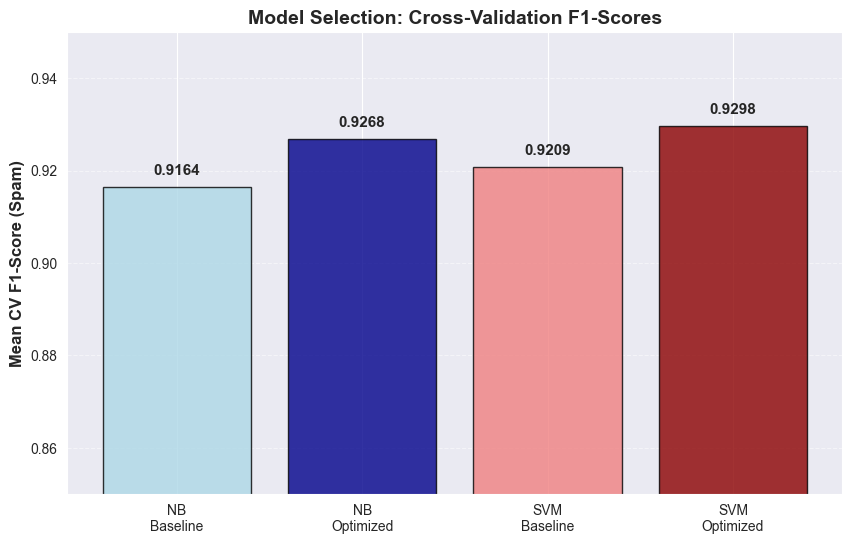

Visualization saved to: optimization_comparison_final.png


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

models = ['NB\nBaseline', 'NB\nOptimized', 'SVM\nBaseline', 'SVM\nOptimized']
f1_scores = [baseline_nb_f1, opt_nb_f1, baseline_svm_f1, opt_svm_f1]
colors = ['lightblue', 'darkblue', 'lightcoral', 'darkred']

plt.figure(figsize=(10, 6))

bars = plt.bar(models, f1_scores, color=colors, alpha=0.8, edgecolor='black')

plt.ylabel('Mean CV F1-Score (Spam)', fontsize=12, fontweight='bold')
plt.title('Model Selection: Cross-Validation F1-Scores', fontsize=14, fontweight='bold')
plt.ylim([0.85, 0.95])  
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.savefig('optimization_comparison_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: optimization_comparison_final.png")

###  Challenges 

**1. Data Leakage Prevention & Evaluation Strategy**
* **The Problem:** Initially, we evaluated our optimization steps (SMOTE, Feature Engineering) directly on the held-out **Test Set**. We realized this approach introduced **Data Leakage**, as optimization decisions were biased by "peeking" at the final test data.
* **The Fix:** We restructured our pipeline to strictly use **5-Fold Stratified Cross-Validation** on the training data for all decision-making. The Test Set was locked away and only used for the final confirmation.
* **Lesson:** This reinforced the golden rule of machine learning: *Optimization uses Validation scores; Evaluation uses Test scores.*

**2. Complexity vs. Efficiency (The SMOTE Dilemma)**
* **The Problem:** We faced a dilemma on whether to use advanced techniques like **SMOTE** and **Manual Feature Engineering**, assuming they would boost performance.
* **The Insight:** rigorous Cross-Validation revealed that:
    * **SMOTE** introduced noise in the high-dimensional text space, degrading SVM performance by ~10%.
    * **Structural Features** (e.g., message length) added negligible value (<0.3%) compared to raw text.
* **The Resolution:** We applied the **Simplicity Principle (Occam's Razor)**, rejecting these complex methods in favor of a robust, standard **Class-Weighted** approach.

### Summary Report — Phase 04: Model Optimization

#### 1. Optimization Process Summary

| Topic | Status | Action & Validation Strategy |
| :--- | :---: | :--- |
| **Model Candidates** | Done | Evaluated MultinomialNB (Probabilistic) and LinearSVC (Geometric). |
| **Hyperparameter Tuning** | Done | Performed `GridSearchCV` (5-fold). Optimized `alpha` for NB and `C` for SVM. |
| **Feature Engineering** | Done | **Rejected via CV:** Structural features did not improve CV scores significantly enough to justify the complexity. |
| **Class Imbalance Strategy** | Done | **Rejected SMOTE:** 5-Fold CV confirmed that **Class Weighting** is superior (SMOTE caused performance degradation). |
| **Final Selection** | Done | Selected **LinearSVC (Optimized)** based on highest Mean CV Score. |

#### 2. Optimization Impact Analysis (Cross-Validation)

The table below confirms the improvements achieved on the Training Data (using 5-Fold CV).

| Model Strategy | Baseline CV F1 | Optimized CV F1 | Improvement | Status |
| :--- | :---: | :---: | :---: | :--- |
| Naive Bayes | 0.9164 | 0.9268 | 🔼 +1.04% | Runner-up |
| **Linear SVM** | 0.9209 | **0.9298** | 🔼 **+0.89%** | 🏆 **CHAMPION** |

#### 3. Key Takeaways & Final Decision

1.  **Optimization Works:** Both models showed clear improvements after hyperparameter tuning. Naive Bayes benefited from vocabulary restriction, while SVM improved with a higher regularization parameter (`C=20`).
2.  **Tight Competition:** The difference between the optimized models is minimal (~0.003), but **SVM** holds a slight statistical advantage on the validation folds.
3.  **Ready for Deployment:** We proceed to **Phase 05** with the **Optimized LinearSVC** model to evaluate its final performance on the held-out Test Set.

In [18]:
import joblib
import json
import os

print("\n" + "="*80)
print("4_FINAL: TRANSFER OPTIMIZED ARTIFACTS TO PHASE 05")
print("="*80)

transfer_dir = os.path.join("..", "results", "model_artifacts")
os.makedirs(transfer_dir, exist_ok=True)
print(f"📂 Saving artifacts to: {os.path.abspath(transfer_dir)}")

# --------------------------------------------------
# 1. SELECT CHAMPION MODEL EXPLICITLY
# --------------------------------------------------
if 'best_svm' in globals():
    best_model = best_svm
    best_model_name = "LinearSVC + TF-IDF (Optimized)"
    print("🏆 Champion Model Selected: SVM")
else:
    raise RuntimeError(
        "❌ Champion SVM model not found. "
        "Make sure best_svm is defined before saving artifacts."
    )

# --------------------------------------------------
# 2. SAVE COMPLETE PIPELINE
# --------------------------------------------------
model_path = os.path.join(transfer_dir, 'phase4_champion_model.joblib')
joblib.dump(best_model, model_path)
print(f"✅ Saved Champion Model Pipeline: {model_path}")

# --------------------------------------------------
# 3. SAVE INDIVIDUAL COMPONENTS
# --------------------------------------------------
best_vectorizer = best_model.named_steps['vect']
best_classifier = best_model.named_steps['clf']

joblib.dump(best_vectorizer,
            os.path.join(transfer_dir, 'phase4_vectorizer.joblib'))
joblib.dump(best_classifier,
            os.path.join(transfer_dir, 'phase4_classifier.joblib'))

print("✅ Saved Vectorizer and Classifier")

# --------------------------------------------------
# 4. SAVE HYPERPARAMETERS & METADATA
# --------------------------------------------------
hyperparams_dict = {
    "model_name": best_model_name,
    "optimization_metric": "F1-Score (Spam)",
    "best_cv_score": float(best_cv_score),

    "vectorizer_params": {
        "max_features": best_vectorizer.max_features,
        "ngram_range": best_vectorizer.ngram_range,
        "min_df": best_vectorizer.min_df
    },

    "classifier_params": {
        "C": getattr(best_classifier, "C", None),
        "class_weight": getattr(best_classifier, "class_weight", None)
    }
}

params_path = os.path.join(transfer_dir, 'phase4_hyperparameters.json')
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(hyperparams_dict, f, indent=4, ensure_ascii=False)

print(f"✅ Saved Metadata: {params_path}")
print("\n📤 TRANSFER COMPLETE: Ready for Phase 05 Evaluation.")



4_FINAL: TRANSFER OPTIMIZED ARTIFACTS TO PHASE 05
📂 Saving artifacts to: c:\Users\ERAM\Desktop\Project_learning\results\model_artifacts
🏆 Champion Model Selected: SVM
✅ Saved Champion Model Pipeline: ..\results\model_artifacts\phase4_champion_model.joblib
✅ Saved Vectorizer and Classifier
✅ Saved Metadata: ..\results\model_artifacts\phase4_hyperparameters.json

📤 TRANSFER COMPLETE: Ready for Phase 05 Evaluation.
